# 1 · Thin airfoil theory

The camber line is replaced by a vortex sheet whose strength is expanded in a Glauert series
in $\theta$, with $x = (1 - \cos\theta)/2$. Only $A_0, A_1, A_2$ matter for the integrated
loads:

$$c_l = 2\pi(\alpha - \alpha_{L0}), \qquad c_{m,c/4} = \frac{\pi}{4}(A_2 - A_1).$$

See [docs/thin_airfoil.md](../docs/thin_airfoil.md) for the derivation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from aero import plotting as P

P.use_style()
DEG = np.pi / 180
from aero.geometry import NACA4
from aero.thin_airfoil import ThinAirfoil

In [2]:
for code in ["0012", "2412", "4412", "6409"]:
    ta = ThinAirfoil.from_naca4(code)
    print(f"NACA {code}:  alpha_L0 = {ta.alpha_zero_lift / DEG:+.3f} deg,  "
          f"cm_c/4 = {ta.cm_quarter_chord:+.4f},  A1 = {ta.A1:.4f}, A2 = {ta.A2:.4f}")

NACA 0012:  alpha_L0 = +0.000 deg,  cm_c/4 = +0.0000,  A1 = 0.0000, A2 = 0.0000
NACA 2412:  alpha_L0 = -2.077 deg,  cm_c/4 = -0.0531,  A1 = 0.0815, A2 = 0.0139
NACA 4412:  alpha_L0 = -4.154 deg,  cm_c/4 = -0.1062,  A1 = 0.1630, A2 = 0.0277
NACA 6409:  alpha_L0 = -6.232 deg,  cm_c/4 = -0.1594,  A1 = 0.2445, A2 = 0.0416


Anderson's worked example gives $\alpha_{L0} = -2.077°$ and $c_{m,c/4} = -0.053$ for the NACA 2412, matching the output above.

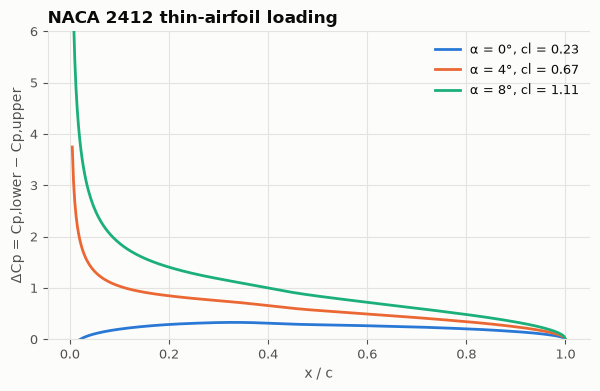

In [3]:
ta = ThinAirfoil.from_naca4("2412")
x = np.linspace(0.005, 1, 400)
fig, ax = plt.subplots(figsize=(7, 4))
for i, a in enumerate([0, 4, 8]):
    ax.plot(x, ta.delta_cp(x, a * DEG), color=P.SERIES[i], label=f"α = {a}°, cl = {ta.cl(a * DEG):.2f}")
ax.set_ylim(0, 6)
ax.set_xlabel("x / c"); ax.set_ylabel("ΔCp = Cp,lower − Cp,upper")
ax.set_title("NACA 2412 thin-airfoil loading"); ax.legend();

The leading-edge singularity of the $A_0$ term is the thin-airfoil model of the suction peak; the camber term ($A_1, A_2$) gives the loading at $\alpha = \alpha_{ideal}$.